# Análise e Classificação de Exoplanetas

Este notebook tem como objetivo analisar o conjunto de dados `cleaned_5250.csv`, realizar um pré-processamento e limpeza, explorar os dados (EDA) e, por fim, treinar e avaliar modelos de classificação (Random Forest e KNN) para prever o tipo de um exoplaneta com base em suas características físicas.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt
import warnings

# Módulos de Pré-processamento e Métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, classification_report, accuracy_score, confusion_matrix

# Modelos
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Configurações
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


In [3]:
# Carregando o dataset
try:
    df_original = pd.read_csv("dataset/cleaned_5250.csv")
except FileNotFoundError:
    print("Erro: Arquivo 'dataset/cleaned_5250.csv' não encontrado.")
    print("Por favor, garanta que o dataset esteja no diretório correto.")
    df_original = pd.DataFrame()

# Criar uma cópia de trabalho para preservar o original
if not df_original.empty:
    df = df_original.copy()
    print("Dataset carregado com sucesso.")
    print(f"Total de {len(df)} registros.")
    df.head(10)

Dataset carregado com sucesso.
Total de 5250 registros.


Antes de começar o tratamento dos dados, note que existem planetas em que o multiplicador de massa e de raio é feito em relação à Jupiter, enquanto outros, são feitos em relação à Terra. Precisaremos normalizar esses dois tipos diferentes de dados. Para isso, irei utilizar como base a massa e o raio de Jupiter (que possui um número maior de recorrências) e transformarei os dados que possuem essa dependência

In [4]:
# Fatores de conversão (aproximados)
# Massa de Júpiter é ~317.8 vezes a massa da Terra
# Raio de Júpiter é ~11.2 vezes o raio da Terra
massa_jupiter_em_terras = 317.8
raio_jupiter_em_terras = 11.2

# --- Conversão da Massa ---
mascara_massa_terra = df['mass_wrt'] == 'Earth'

df.loc[mascara_massa_terra, 'mass_multiplier'] = df.loc[mascara_massa_terra, 'mass_multiplier'] / massa_jupiter_em_terras

# --- Conversão do Raio ---
mascara_raio_terra = df['radius_wrt'] == 'Earth'

df.loc[mascara_raio_terra, 'radius_multiplier'] = df.loc[mascara_raio_terra, 'radius_multiplier'] / raio_jupiter_em_terras

# Excluindo as colunas 'radius_wrt' e 'mass_wrt', que agora são inúteis:

df = df.drop(['mass_wrt','radius_wrt'],axis=1)


Agora, precisamos extrair algumas informações que sejam relevantes que saíbamos utilizar antes de começar o treinamento, como se existem valores ausentes no datagrame. Para isso, podemos usar o método isnull do pandas:

In [5]:
df.isnull().any()

name                 False
distance              True
stellar_magnitude     True
planet_type          False
discovery_year       False
mass_multiplier       True
radius_multiplier     True
orbital_radius        True
orbital_period       False
eccentricity         False
detection_method     False
dtype: bool

Como foi possível perceber acima, existem valores nulos no dataframe. Esses valores podem contribuir negativamente para a qualidade do nosso estimador.

Precisamos tratar de alguma forma o nosso conjunto de dados para substituir esses valores. Existem algumas técnicas para contornar essa situação, como inserir na posição dos valores faltantes a média ou a mediana dos valores de cada uma das colunas. Também é possível usar um modelo de regressão para preencher esses valores em função das outras colunas.

Sabemos que a média é sensível a outliers, para verificar se esse é o caso do nosso dataframe, vamos plotar o boxplot do dataframe:

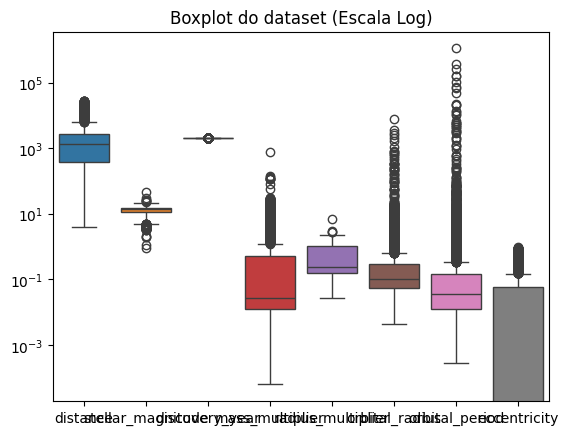

In [6]:
# Oculta avisos de log-scale que podem aparecer
warnings.simplefilter(action='ignore', category=RuntimeWarning)

sns.boxplot(data=df)
plt.title('Boxplot do dataset (Escala Log)')
plt.yscale("log") # Usar escala logarítmica devido à grande variação de valores
plt.show()

### Análise dos Outliers

O boxplot em escala logarítmica confirma o que suspeitávamos: colunas como `orbital_radius` e `orbital_period` têm uma enorme quantidade de outliers (valores extremos).

Isso reforça a decisão de **não** usar a média ou mediana para preencher valores ausentes (NaNs), pois essas métricas seriam fortemente distorcidas pelos outliers. Uma estratégia baseada em regressão é muito mais robusta neste caso.

In [7]:
df = df.drop(columns=['distance','name', 'discovery_year', 'detection_method']) # Removendo as colunas desnecessárias

df = df[df['planet_type'] != 'Unknown'] # Removendo os planetas de tipo "Unknown" do dataframe

df = pd.get_dummies(df) # Aplicando OneHotEncoding

columns_with_null = df.columns[df.isnull().any()].tolist() # Salvando o nome das colunas que possuem elementos NaNs

df = df.fillna(0) # Trocando os NaNs por 0

df


,stellar_magnitude,mass_multiplier,radius_multiplier,orbital_radius,orbital_period,eccentricity,planet_type_Gas Giant,planet_type_Neptune-like,planet_type_Super Earth,planet_type_Terrestrial
0,4.72307,19.400000,1.080000,1.290000,0.892539,0.23,True,False,False,False
1,5.01300,14.740000,1.090000,1.530000,1.400000,0.08,True,False,False,False
2,5.23133,4.800000,1.150000,0.830000,0.508693,0.00,True,False,False,False
3,6.61935,8.138810,1.120000,2.773069,4.800000,0.37,True,False,False,False
4,6.21500,1.780000,1.200000,1.660000,2.200000,0.68,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
5245,10.52100,0.709000,1.373000,0.044210,0.007940,0.04,True,False,False,False
5246,10.88500,6.300000,1.140000,115.000000,1176.500000,0.00,True,False,False,False
5247,12.07400,0.002203,0.081518,0.016340,0.005476,0.06,False,False,False,True
5248,12.07400,0.003587,0.093750,0.021560,0.008487,0.00,False,False,True,False


Como foi possível perceber, existe um número considerável de outliers em quase todas as colunas do conjunto de dados, o que inviabiliza de preenchermos esses dados simplesmente com a média da coluna, que é uma métrica altamente sensível à outliers.

No entanto, podemos ajustar um modelo de regressão para cada uma das colunas com dados faltantes em função dos outros atributos e preencher esses os valores faltantes com os valores gerados a partir desse modelo.

Farei uma função que recebe como entrada a coluna desejada e o próprio dataframe e calcula um modelo de Random Regression a partir dos outros atributos. O valor de retorno será o Dataframe com o valor da coluna corrigida.

### Estratégia de Imputação (Random Forest Regressor)

Como a média/mediana não são viáveis, usaremos um modelo de regressão para prever os valores ausentes (marcados como 0).

Criaremos uma função `fill_columns` que:
1.  Toma uma coluna-alvo (ex: `mass_multiplier`).
2.  Define como `X` todas as *outras* colunas numéricas.
3.  Treina um `RandomForestRegressor` **apenas** nas linhas onde a coluna-alvo *não* era 0 (ou seja, `y != 0`).
4.  Usa o modelo treinado para prever os valores das linhas que *eram* 0.
5.  Retorna a coluna agora preenchida.

Isso garante que o modelo aprenda a relação entre as features usando apenas dados válidos.

In [8]:
def fill_columns(df: pd.DataFrame, column: str):

    y = df[column]
    name_column = y.name

    # Seleciona todas as colunas numéricas como features, exceto a própria coluna
    X = df.select_dtypes(include='number').drop(name_column, axis=1)

    # 1. Dados de Treino são APENAS as linhas que NÃO eram NaN (ou seja, != 0)
    X_train_data = X[y != 0]
    y_train_data = y[y != 0]

    # 2. Dados a Prever são APENAS as linhas que eram NaN (ou seja, == 0)
    X_to_predict = X[y == 0]

    # Se não houver dados de treino (caso raro), apenas retorne a coluna como está
    if X_train_data.empty:
        print(f"Sem dados de treino para a coluna {name_column}, pulando.")
        return y

    # 3. Treinar o modelo APENAS com os dados conhecidos
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train_data, y_train_data)

    # 4. Avaliar o modelo (Opcional, mas bom)
    try:
        X_train_eval, X_test_eval, y_train_eval, y_test_eval = train_test_split(X_train_data, y_train_data, test_size=0.3, random_state=42)
        model_eval = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        model_eval.fit(X_train_eval, y_train_eval)
        y_pred_eval = model_eval.predict(X_test_eval)

        RMSE = sqrt(mean_squared_error(y_true=y_test_eval, y_pred=y_pred_eval))
        r2 = r2_score(y_true=y_test_eval, y_pred=y_pred_eval)
        print(f'Coluna (Imputação): {name_column} | RMSE: {RMSE:.4f} | R2: {r2:.4f}')
    except Exception as e:
        print(f"Não foi possível avaliar a imputação para {name_column}: {e}")

    # 5. Prever os valores para TODAS as linhas
    y_pred_all = model.predict(X)

    y_filled = y.copy()
    zero_indices = y[y == 0].index

    # 6. Substituir APENAS os 0s pelas predições
    y_filled.loc[zero_indices] = y_pred_all[zero_indices]

    return y_filled

Com a função criada, vamos aplica-lá nas colunas com dados nulos:

In [9]:
print("Iniciando imputação com RandomForestRegressor...")
df_reg = df.copy(deep=True)
for column in columns_with_null:
    new_column = fill_columns(df_reg, column)
    df_reg[column] = pd.Series(new_column)

print("\nImputação concluída. DataFrame 'df_reg' criado.")

Iniciando imputação com RandomForestRegressor...
Coluna (Imputação): stellar_magnitude | RMSE: 2.1756 | R2: 0.5119
Coluna (Imputação): mass_multiplier | RMSE: 6.8085 | R2: 0.1507
Coluna (Imputação): radius_multiplier | RMSE: 0.1302 | R2: 0.9219
Coluna (Imputação): orbital_radius | RMSE: 62.6402 | R2: 0.7770

Imputação concluída. DataFrame 'df_reg' criado.


Conforme foi possível perceber, conseguimos fazer o tratamento dos dados faltantes no dataset e agora podemos partir para a Análise Explorátoria dos Dados (EDA). Focaremos em realizar:

- Gráfico Massa x Raio (Scatter Plot)

- Distribuição do Período Orbital dos Planetas

- Matriz de Correlação






In [10]:
# Lista das colunas one-hot encoded para o tipo de planeta
planet_type_cols = [
    'planet_type_Gas Giant',
    'planet_type_Neptune-like',
    'planet_type_Super Earth',
    'planet_type_Terrestrial',
]

# Usa idxmax para encontrar o nome da coluna com valor True (1) em cada linha
# e remove o prefixo 'planet_type_' para limpar os nomes
df_reg['planet_type'] = df_reg[planet_type_cols].idxmax(axis=1).str.replace('planet_type_', '')
df['planet_type'] = df[planet_type_cols].idxmax(axis=1).str.replace('planet_type_', '')

### Gráfico Massa x Raio

Primeiro, vamos realizar o gráfico Massa x Raio. A coluna `planet_type` (criada na célula anterior) será usada para colorir os pontos, permitindo-nos ver agrupamentos.

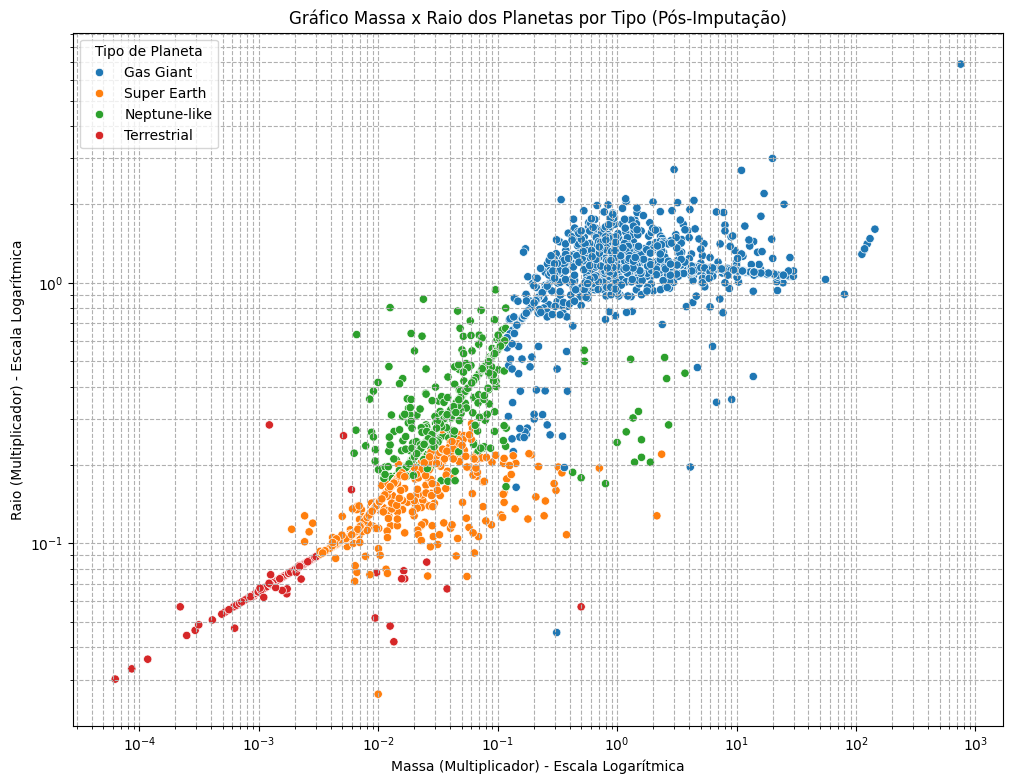

In [11]:
# Define o tamanho da figura para melhor visualização com a legenda
plt.figure(figsize=(12, 9))

# Cria o scatter plot, usando 'hue' para colorir os pontos por 'planet_type'
sns.scatterplot(data=df_reg, x='mass_multiplier', y='radius_multiplier', hue='planet_type')

# Adiciona títulos e rótulos
plt.title('Gráfico Massa x Raio dos Planetas por Tipo (Pós-Imputação)')
plt.xlabel('Massa (Multiplicador) - Escala Logarítmica')
plt.ylabel('Raio (Multiplicador) - Escala Logarítmica')

# Usa escala logarítmica para melhor visualização
plt.xscale('log')
plt.yscale('log')

# Adiciona uma grade e uma legenda
plt.grid(True, which="both", ls="--")
plt.legend(title='Tipo de Planeta')

# Mostra o gráfico
plt.show()

Analisando o Scatter-Plot de Raio x Massa, conseguimos perceber algumas coisas interessantes:

- Planetas Terrestres tendem a possuir uma densidade equivalente (Massa e Raio crescem de forma linear e igualmente)

- Existe um certo número de planetas observados que possuem densidade parecidas(As linhas crescentes observadas)

- A falta de planetas observáveis na região entre 'Tipo-Netuno' e 'Super-Terras'. Na literatura de astronomia, essa 'lacuna' é conhecida como: 'Radius Valley'

- Gigantes Gasosos tendem a ser menos densos que Super Terras


### Distribuição do Período Orbital

Agora, vamos analisar o período orbital dos planetas. Devido à grande variação (viés de observação), usaremos uma escala logarítmica no eixo X.

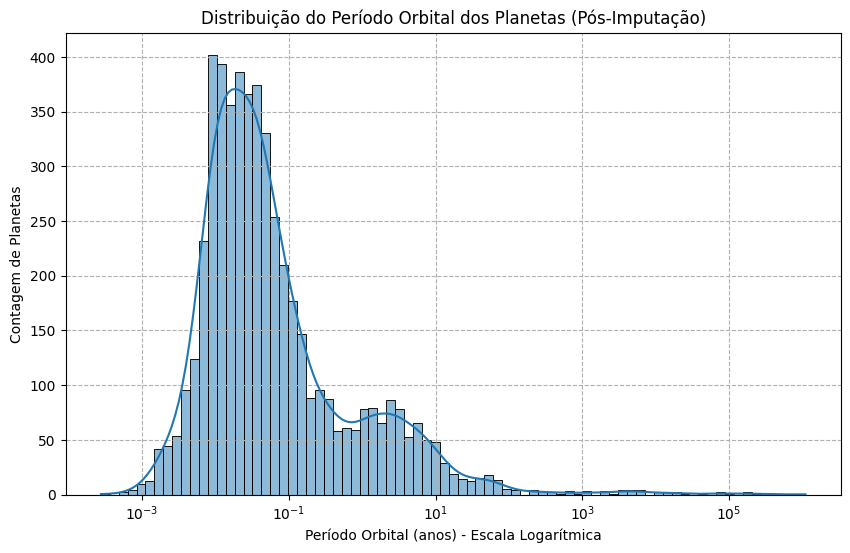

In [12]:
# Cria a figura e define o tamanho
plt.figure(figsize=(10, 6))

# Cria o histograma para a coluna 'orbital_period'.
sns.histplot(data=df_reg, x='orbital_period', kde=True, log_scale=True)

# Define o título e os rótulos dos eixos
plt.title('Distribuição do Período Orbital dos Planetas (Pós-Imputação)')
plt.xlabel('Período Orbital (anos) - Escala Logarítmica')
plt.ylabel('Contagem de Planetas')

# Adiciona uma grade
plt.grid(True, which="both", ls="--")

# Exibe o gráfico
plt.show()

Conforme é possível observar, existe uma observação maior de exoplanetas que possuem um período orbital menor. Essa maior concentração se deve às formas mais comuns e eficientes de identificar um exoplaneta, que são a Técnica de Trânsito e a Velocidade Radial, que consiste em identificar o planeta justamente pelo seu período de órbita. Planetas com um período elevado de órbita são dificilmente encontrados utilizando esse método

### Matriz de Correlação (Dados Imputados)

Finalmente, vamos analisar a matriz de correlação. É crucial usar o `df_reg` (dados imputados) em vez do `df` (com zeros), pois os zeros artificiais distorceriam as correlações.

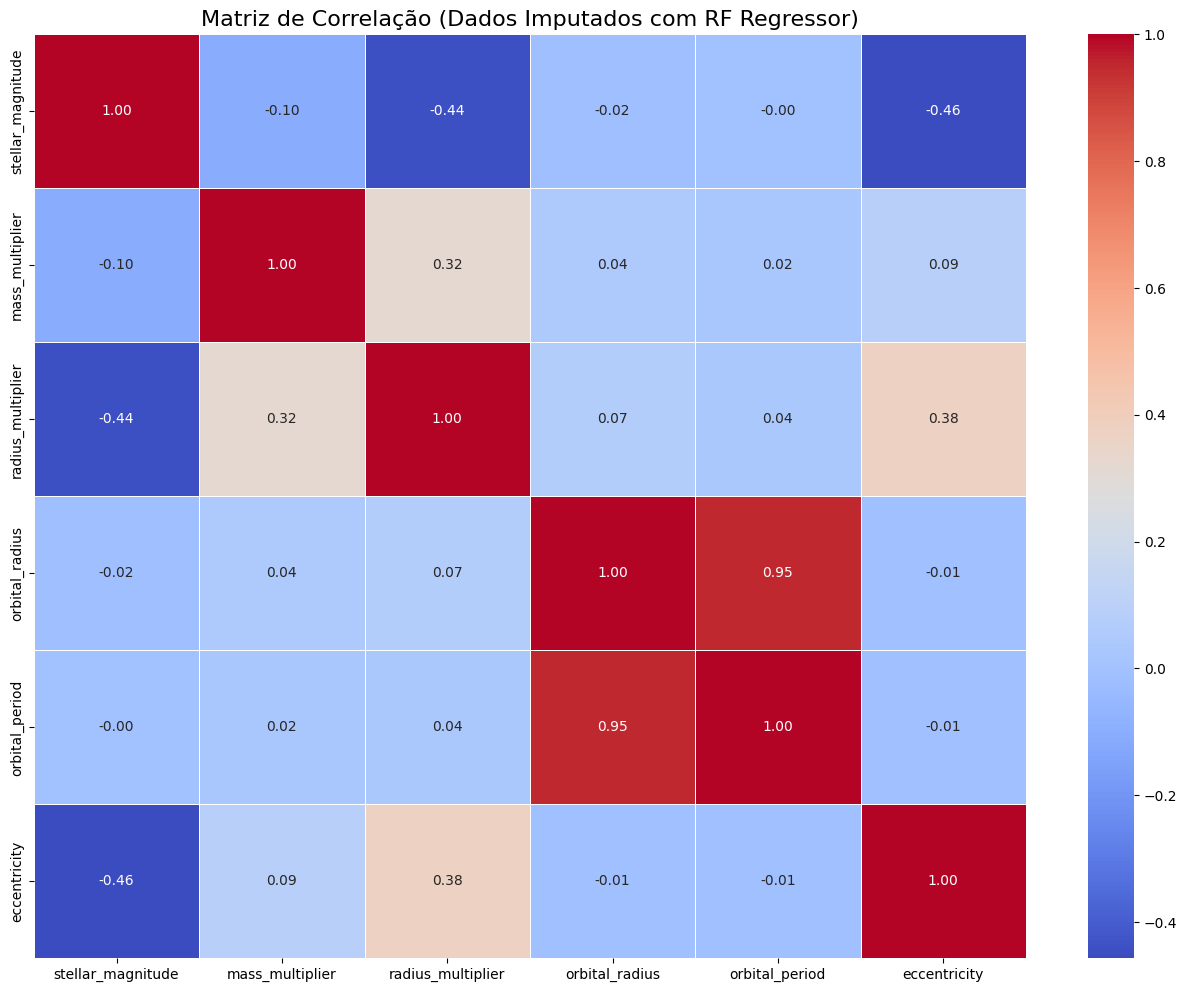

In [13]:
# 1. Selecionar apenas colunas numéricas do df_reg (o imputado)
numeric_df_reg = df_reg.select_dtypes(include='number')

# 2. Calcular a matriz de correlação no df_reg
corr_matrix = numeric_df_reg.corr()

# 3. Plotar o heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação (Dados Imputados com RF Regressor)', fontsize=16)
plt.show()

## 4. Classificação de Tipos de Planetas (Random Forest)

Com os dados limpos e imputados (`df_reg`), agora vamos treinar um modelo `RandomForestClassifier` para prever a coluna `planet_type` com base nas características físicas dos planetas.

Iniciando o treinamento do classificador Random Forest...
Total de amostras para classificação: 5245
Distribuição das classes no target:
planet_type
Neptune-like    0.347950
Gas Giant       0.310772
Super Earth     0.304099
Terrestrial     0.037178
Name: proportion, dtype: float64

Tamanho do conjunto de treino: 3671 amostras
Tamanho do conjunto de teste: 1574 amostras

Treinando o modelo de classificação...
Treinamento concluído.

--- Avaliação do Modelo no Conjunto de Teste ---
Acurácia: 0.9720

Relatório de Classificação:
              precision    recall  f1-score   support

   Gas Giant       0.98      1.00      0.99       489
Neptune-like       0.96      0.97      0.96       548
 Super Earth       0.98      0.95      0.96       479
 Terrestrial       0.97      0.97      0.97        58

    accuracy                           0.97      1574
   macro avg       0.97      0.97      0.97      1574
weighted avg       0.97      0.97      0.97      1574

Matriz de Confusão:


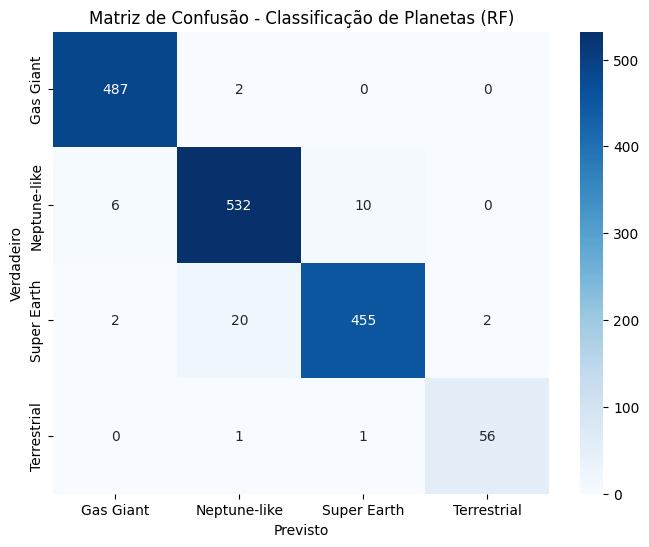


Importância das Features:
mass_multiplier      0.432203
radius_multiplier    0.420888
orbital_radius       0.058877
orbital_period       0.053985
stellar_magnitude    0.021296
eccentricity         0.012751
dtype: float64


In [14]:
def treinar_classificador_planetas(df_treino):
    """
    Treina um RandomForestClassifier para prever o tipo do planeta.
    """
    print("Iniciando o treinamento do classificador Random Forest...")

    # 1. Definir Features (X) e Target (y)
    feature_cols = [
        'stellar_magnitude',
        'mass_multiplier',
        'radius_multiplier',
        'orbital_radius',
        'orbital_period',
        'eccentricity'
    ]
    target_col = 'planet_type'

    X = df_treino[feature_cols]
    y = df_treino[target_col]

    print(f"Total de amostras para classificação: {len(y)}")
    print(f"Distribuição das classes no target:\n{y.value_counts(normalize=True)}\n")

    # 2. Dividir os dados em Treino e Teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
    print(f"Tamanho do conjunto de teste: {len(X_test)} amostras\n")

    # 3. Inicializar e Treinar o Modelo
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

    print("Treinando o modelo de classificação...")
    model.fit(X_train, y_train)
    print("Treinamento concluído.\n")

    # 4. Avaliar o Modelo
    print("--- Avaliação do Modelo no Conjunto de Teste ---")
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Acurácia: {accuracy:.4f}\n")

    print("Relatório de Classificação:")
    print(classification_report(y_test, y_pred))

    print("Matriz de Confusão:")
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title('Matriz de Confusão - Classificação de Planetas (RF)')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Previsto')
    plt.show()

    print("\nImportância das Features:")
    features_importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print(features_importance)

    # 5. Retornar tudo o que é necessário para as próximas etapas
    # Retornamos os dados divididos para reutilizar na curva de aprendizado
    return model, X_train, X_test, y_train, y_test, feature_cols

# --- Execução ---
if 'df_reg' in locals():
    # Armazena as saídas da função em variáveis
    modelo_rf, X_train_rf, X_test_rf, y_train_rf, y_test_rf, feature_cols = treinar_classificador_planetas(df_reg)
else:
    print("Erro: DataFrame 'df_reg' não encontrado.")

In [15]:
from sklearn.model_selection import GridSearchCV

print("Iniciando o ajuste de hiperparâmetros com GridSearchCV...")

# 1. Definir a grade de parâmetros que queremos testar
# (Estes são alguns parâmetros comuns para o Random Forest)
param_grid = {
    'n_estimators': [100, 200],          # Número de árvores
    'max_depth': [None, 10, 20],         # Profundidade máxima da árvore
    'min_samples_split': [2, 5],         # Mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2]           # Mínimo de amostras em um nó folha
}

# 2. Inicializar o GridSearchCV
# Usaremos o modelo base RandomForestClassifier
# cv=5 significa 5-fold cross-validation
# n_jobs=-1 usa todos os processadores para acelerar
rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_base,
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           verbose=2,
                           scoring='accuracy')

# 3. Treinar o GridSearchCV nos dados de treino
# (Usando as variáveis X_train_rf e y_train_rf que você já criou)
grid_search.fit(X_train_rf, y_train_rf)

print("\nAjuste de hiperparâmetros concluído.")

# 4. Exibir os melhores parâmetros encontrados
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}\n")

# 5. Avaliar o melhor modelo encontrado no conjunto de teste
print("--- Avaliação do Melhor Modelo (Tuned RF) no Conjunto de Teste ---")

# O grid_search.best_estimator_ já é o modelo treinado com os melhores parâmetros
best_rf_model = grid_search.best_estimator_
y_pred_tuned_rf = best_rf_model.predict(X_test_rf)

# Exibir a nova acurácia e o relatório
accuracy_tuned = accuracy_score(y_test_rf, y_pred_tuned_rf)
print(f"Acurácia (RF Tuned): {accuracy_tuned:.4f}\n")

print("Relatório de Classificação (RF Tuned):")
print(classification_report(y_test_rf, y_pred_tuned_rf))

Iniciando o ajuste de hiperparâmetros com GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.7s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estim

Iniciando o treinamento do classificador Random Forest...
Total de amostras para classificação: 5245
Distribuição das classes no target:
planet_type
Neptune-like    0.347950
Gas Giant       0.310772
Super Earth     0.304099
Terrestrial     0.037178
Name: proportion, dtype: float64

Tamanho do conjunto de treino: 3671 amostras
Tamanho do conjunto de teste: 1574 amostras

Treinando o modelo de classificação...
Treinamento concluído.

--- Avaliação do Modelo no Conjunto de Teste ---
Acurácia: 0.9720

Relatório de Classificação:
              precision    recall  f1-score   support

   Gas Giant       0.98      1.00      0.99       489
Neptune-like       0.96      0.97      0.96       548
 Super Earth       0.98      0.95      0.96       479
 Terrestrial       0.97      0.97      0.97        58

    accuracy                           0.97      1574
   macro avg       0.97      0.97      0.97      1574
weighted avg       0.97      0.97      0.97      1574

Matriz de Confusão:


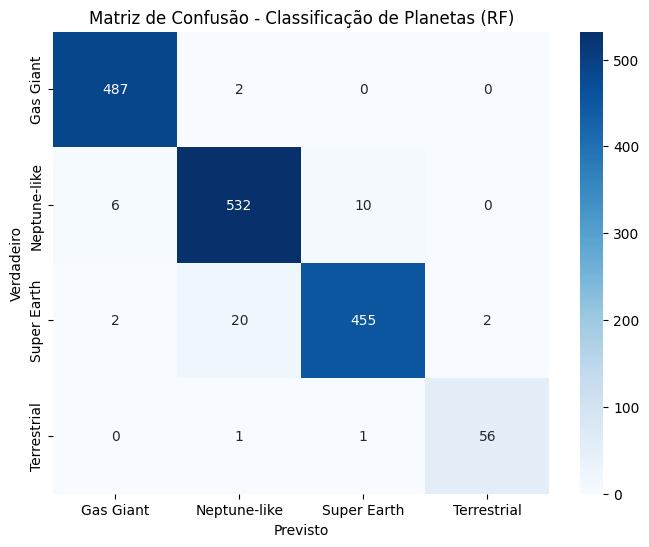


Importância das Features:
mass_multiplier      0.432203
radius_multiplier    0.420888
orbital_radius       0.058877
orbital_period       0.053985
stellar_magnitude    0.021296
eccentricity         0.012751
dtype: float64


In [16]:
def treinar_classificador_planetas(df_treino):
    """
    Treina um RandomForestClassifier para prever o tipo do planeta.
    """
    print("Iniciando o treinamento do classificador Random Forest...")

    # 1. Definir Features (X) e Target (y)
    feature_cols = [
        'stellar_magnitude',
        'mass_multiplier',
        'radius_multiplier',
        'orbital_radius',
        'orbital_period',
        'eccentricity'
    ]
    target_col = 'planet_type'

    X = df_treino[feature_cols]
    y = df_treino[target_col]

    print(f"Total de amostras para classificação: {len(y)}")
    print(f"Distribuição das classes no target:\n{y.value_counts(normalize=True)}\n")

    # 2. Dividir os dados em Treino e Teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
    print(f"Tamanho do conjunto de teste: {len(X_test)} amostras\n")

    # 3. Inicializar e Treinar o Modelo
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

    print("Treinando o modelo de classificação...")
    model.fit(X_train, y_train)
    print("Treinamento concluído.\n")

    # 4. Avaliar o Modelo
    print("--- Avaliação do Modelo no Conjunto de Teste ---")
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Acurácia: {accuracy:.4f}\n")

    print("Relatório de Classificação:")
    print(classification_report(y_test, y_pred))

    print("Matriz de Confusão:")
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title('Matriz de Confusão - Classificação de Planetas (RF)')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Previsto')
    plt.show()

    print("\nImportância das Features:")
    features_importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print(features_importance)

    # 5. Retornar tudo o que é necessário para as próximas etapas
    # Retornamos os dados divididos para reutilizar na curva de aprendizado
    return model, X_train, X_test, y_train, y_test, feature_cols

# --- Execução ---
if 'df_reg' in locals():
    # Armazena as saídas da função em variáveis
    modelo_rf, X_train_rf, X_test_rf, y_train_rf, y_test_rf, feature_cols = treinar_classificador_planetas(df_reg)
else:
    print("Erro: DataFrame 'df_reg' não encontrado.")

### Inferência com Random Forest

Agora, vamos usar o modelo `modelo_rf_classificacao` treinado para prever o tipo de dois planetas hipotéticos.

## 5. Classificação de Tipos de Planetas (KNN)

Agora, vamos treinar um segundo modelo, o K-Nearest Neighbors (KNN), para comparar os resultados com o Random Forest.

**Importante:** Modelos baseados em distância, como o KNN, exigem que as features estejam na mesma escala. Vamos usar o `StandardScaler` para padronizar nossos dados (massa, raio, etc.) antes do treinamento.

Iniciando o treinamento do classificador K-Nearest Neighbors (KNN)...
Padronizando as features (Scaling)...
Padronização concluída.

Treinando o modelo KNN...
Treinamento concluído.

--- Avaliação do Modelo KNN no Conjunto de Teste ---
Acurácia: 0.9314

Relatório de Classificação:
              precision    recall  f1-score   support

   Gas Giant       0.99      0.97      0.98       489
Neptune-like       0.88      0.95      0.92       548
 Super Earth       0.93      0.89      0.91       479
 Terrestrial       0.90      0.79      0.84        58

    accuracy                           0.93      1574
   macro avg       0.93      0.90      0.91      1574
weighted avg       0.93      0.93      0.93      1574

Matriz de Confusão (KNN):


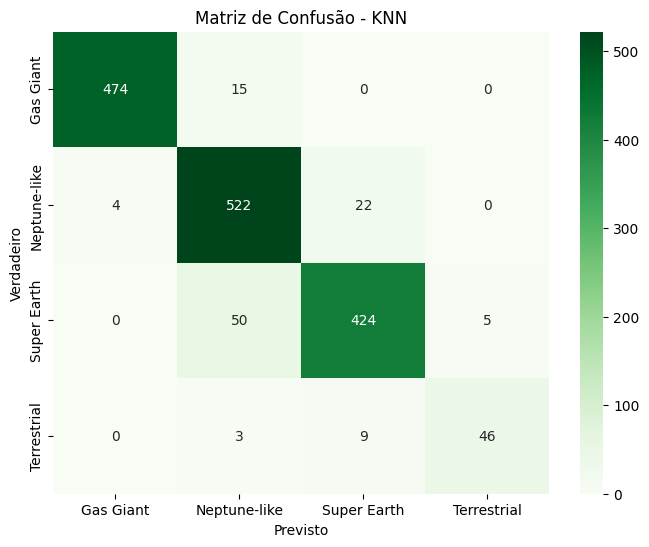

In [17]:
def treinar_classificador_knn(df_treino, feature_cols, target_col):
    """
    Treina um KNeighborsClassifier para prever o tipo do planeta,
    aplicando a padronização de features.
    """
    print("Iniciando o treinamento do classificador K-Nearest Neighbors (KNN)...")

    # 1. Definir Features (X) e Target (y)
    X = df_treino[feature_cols]
    y = df_treino[target_col]

    # 2. Dividir os dados (mesma divisão do RF para comparação justa)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # 3. Padronizar os Dados (Etapa CRÍTICA para o KNN)
    print("Padronizando as features (Scaling)...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("Padronização concluída.\n")

    # 4. Inicializar e Treinar o Modelo KNN
    model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

    print("Treinando o modelo KNN...")
    model.fit(X_train_scaled, y_train)
    print("Treinamento concluído.\n")

    # 5. Avaliar o Modelo
    print("--- Avaliação do Modelo KNN no Conjunto de Teste ---")
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Acurácia: {accuracy:.4f}\n")

    print("Relatório de Classificação:")
    print(classification_report(y_test, y_pred))

    print("Matriz de Confusão (KNN):")
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title('Matriz de Confusão - KNN')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Previsto')
    plt.savefig('confusion_matrix_knn.png')
    plt.show()

    # 6. Retornar tudo o que é necessário
    return model, scaler, X_train_scaled, X_test_scaled, y_train, y_test

# --- Execução ---
if 'df_reg' in locals():
    # Passamos as colunas definidas na célula RF
    modelo_knn, scaler_knn, X_train_knn, X_test_knn, y_train_knn, y_test_knn = treinar_classificador_knn(df_reg, feature_cols, 'planet_type')
else:
    print("Erro: DataFrame 'df_reg' não encontrado.")

In [18]:
# --- Exemplo de Inferência com KNN ---
print("\n\n--- Exemplo de Inferência (KNN) ---")

# Usamos o mesmo DataFrame 'df_inferencia' da célula 126
# (planeta_terra_like e planeta_hot_jupiter)
print(f"Dados dos planetas hipotéticos (originais):\n{df_inferencia}")

# 1. ESCALAR os dados de inferência
# Usamos o MESMO scaler que foi treinado ('scaler_knn')
X_inferencia_scaled = scaler_knn.transform(df_inferencia)
print(f"\nDados dos planetas (escalados para KNN):\n{X_inferencia_scaled}")

# 2. Fazer a predição com o modelo KNN
predicao_tipos_knn = modelo_knn.predict(X_inferencia_scaled)
predicao_probas_knn = modelo_knn.predict_proba(X_inferencia_scaled)

print("\nResultados da Predição (KNN):")
for i, tipo in enumerate(predicao_tipos_knn):
    print(f"\nPlaneta {i+1}: Tipo Previsto = {tipo}")
    print(f"  Probabilidades (KNN):")
    for j, classe in enumerate(modelo_knn.classes_):
        print(f"    {classe}: {predicao_probas_knn[i][j]:.4f}")



--- Exemplo de Inferência (KNN) ---


NameError: name 'df_inferencia' is not defined

Gerando curvas de aprendizado para Random Forest e KNN...
Iterando sobre os tamanhos de treino: [ 367  734 1101 1468 1835 2202 2569 2936 3303]
Cálculo dos erros concluído. Gerando gráficos...


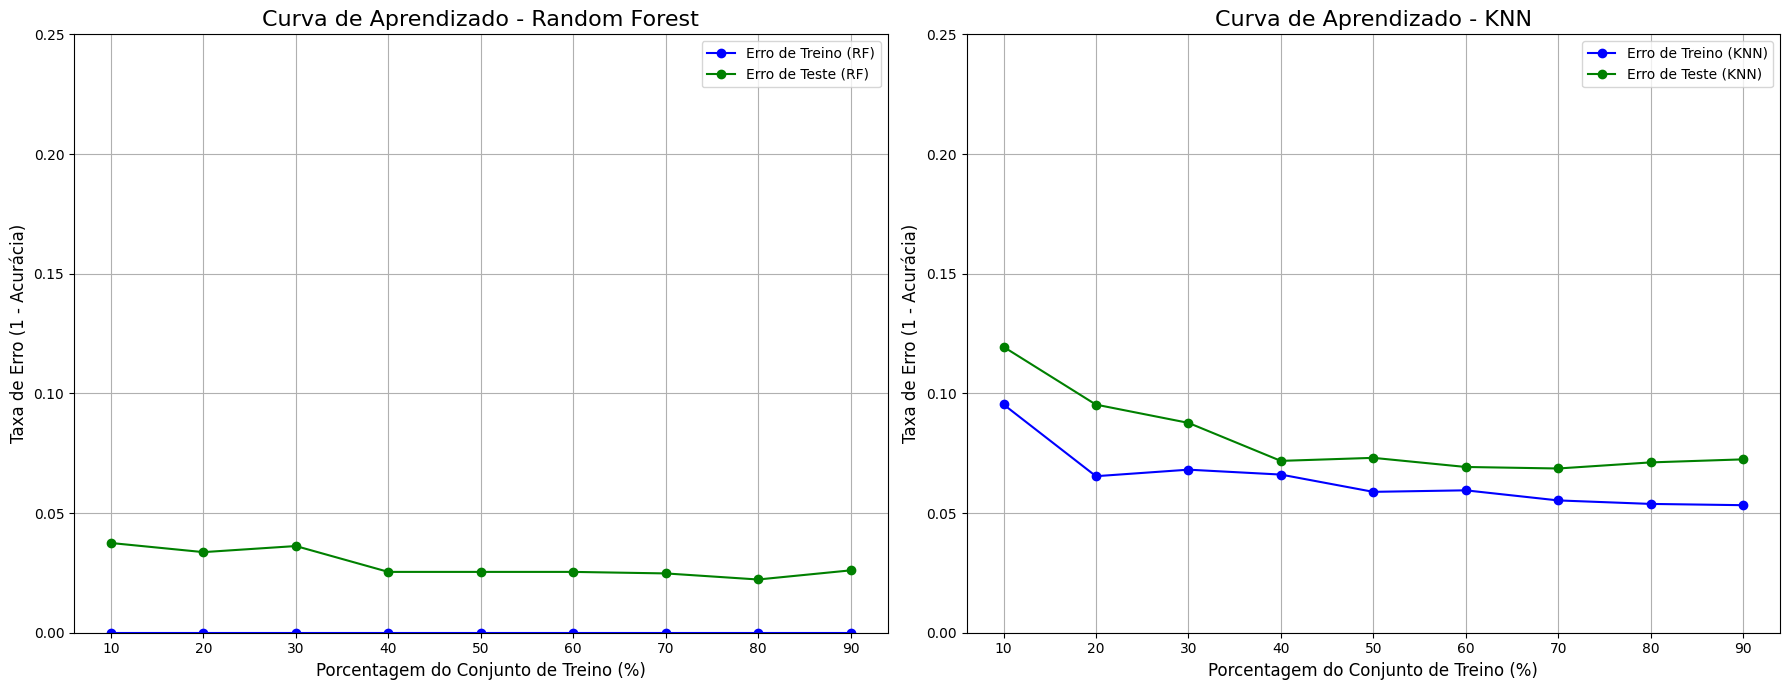

In [ ]:
print("Gerando curvas de aprendizado para Random Forest e KNN...")

# --- 1. Definir os tamanhos das fatias de treino ---
# (Já temos X_train_rf, X_test_rf, y_train_rf, y_test_rf do RF)
# (Já temos X_train_knn, X_test_knn, y_train_knn, y_test_knn do KNN)

train_sizes_perc = np.linspace(0.1, 0.9, 9)
train_sizes_abs = (train_sizes_perc * len(X_train_rf)).astype(int)

# Listas para armazenar os erros
rf_train_errors = []
rf_test_errors = []
knn_train_errors = []
knn_test_errors = []

print(f"Iterando sobre os tamanhos de treino: {train_sizes_abs}")

# --- 2. Loop de Treinamento ---
for size in train_sizes_abs:
    # Fatiar os dados de TREINO
    X_train_subset_rf = X_train_rf[:size]
    X_train_subset_knn = X_train_knn[:size]
    y_train_subset = y_train_rf[:size] # y_train é o mesmo para ambos

    # --- a. Random Forest ---
    model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model_rf.fit(X_train_subset_rf, y_train_subset)

    # Erro de Treino (RF)
    y_pred_train_rf = model_rf.predict(X_train_subset_rf)
    train_acc_rf = accuracy_score(y_train_subset, y_pred_train_rf)
    rf_train_errors.append(1 - train_acc_rf)

    # Erro de Teste (RF)
    y_pred_test_rf = model_rf.predict(X_test_rf) # Usa o X_test do RF
    test_acc_rf = accuracy_score(y_test_rf, y_pred_test_rf)
    rf_test_errors.append(1 - test_acc_rf)

    # --- b. KNN ---
    model_knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    model_knn.fit(X_train_subset_knn, y_train_subset)

    # Erro de Treino (KNN)
    y_pred_train_knn = model_knn.predict(X_train_subset_knn)
    train_acc_knn = accuracy_score(y_train_subset, y_pred_train_knn)
    knn_train_errors.append(1 - train_acc_knn)

    # Erro de Teste (KNN)
    y_pred_test_knn = model_knn.predict(X_test_knn) # Usa o X_test_scaled do KNN
    test_acc_knn = accuracy_score(y_test_knn, y_pred_test_knn)
    knn_test_errors.append(1 - test_acc_knn)

print("Cálculo dos erros concluído. Gerando gráficos...")

# --- 3. Plotar os Gráficos ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Random Forest
ax1.plot(train_sizes_perc * 100, rf_train_errors, 'o-', color='blue', label='Erro de Treino (RF)')
ax1.plot(train_sizes_perc * 100, rf_test_errors, 'o-', color='green', label='Erro de Teste (RF)')
ax1.set_title('Curva de Aprendizado - Random Forest', fontsize=16)
ax1.set_xlabel('Porcentagem do Conjunto de Treino (%)', fontsize=12)
ax1.set_ylabel('Taxa de Erro (1 - Acurácia)', fontsize=12)
ax1.legend()
ax1.grid(True)
ax1.set_ylim(0, 0.25)

# Gráfico 2: KNN
ax2.plot(train_sizes_perc * 100, knn_train_errors, 'o-', color='blue', label='Erro de Treino (KNN)')
ax2.plot(train_sizes_perc * 100, knn_test_errors, 'o-', color='green', label='Erro de Teste (KNN)')
ax2.set_title('Curva de Aprendizado - KNN', fontsize=16)
ax2.set_xlabel('Porcentagem do Conjunto de Treino (%)', fontsize=12)
ax2.set_ylabel('Taxa de Erro (1 - Acurácia)', fontsize=12)
ax2.legend()
ax2.grid(True)
ax2.set_ylim(0, 0.25)

plt.tight_layout()
plt.savefig('curvas_de_aprendizado_comparacao.png')
plt.show()

Gerando PCA com Transformação Logarítmica...


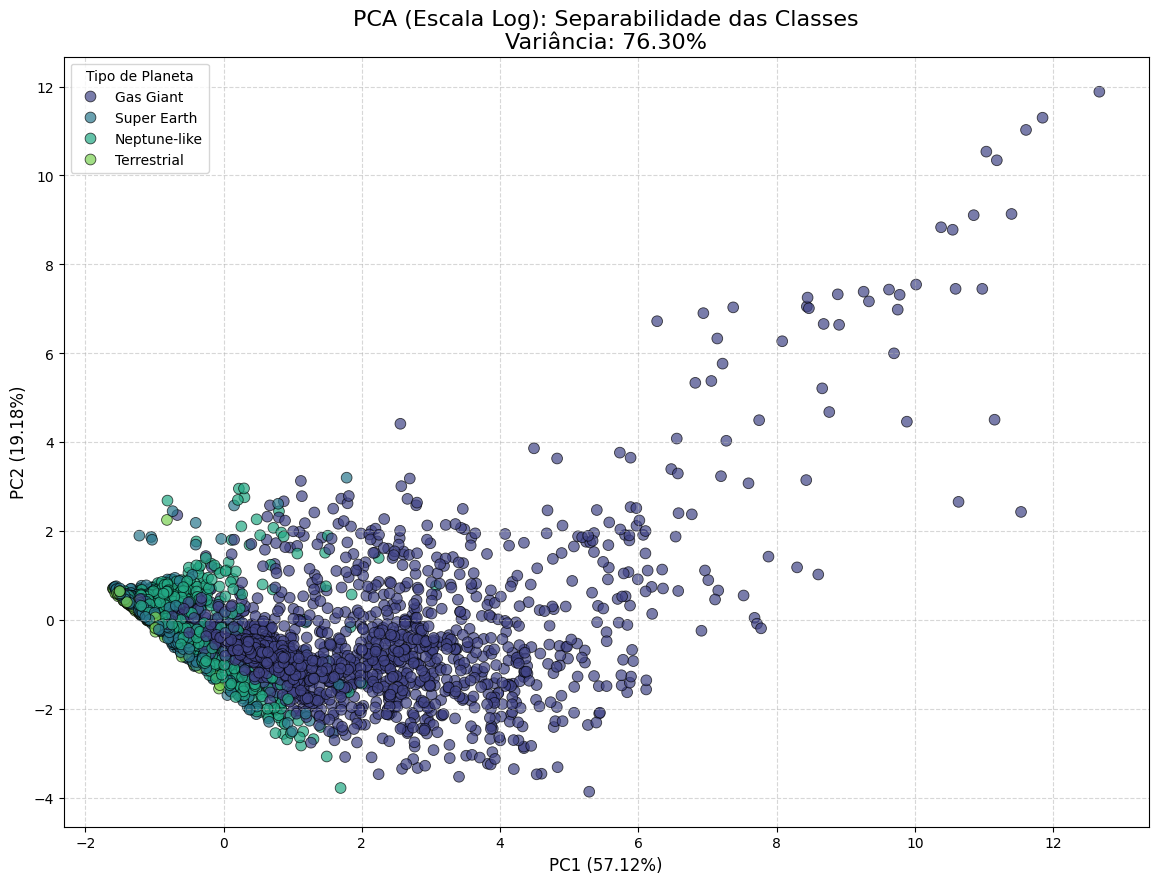

In [ ]:
import numpy as np

print("Gerando PCA com Transformação Logarítmica...")

# 1. Definir Features e Target
features = ['mass_multiplier', 'radius_multiplier', 'orbital_radius',
            'orbital_period', 'stellar_magnitude', 'eccentricity']
target = 'planet_type'

X = df_reg[features].copy()
y = df_reg[target]

# --- TRUQUE DO LOG ---
# Aplicamos log nas colunas que têm crescimento exponencial (Massa, Raio, Período, Distância)
# Adicionamos +1 (np.log1p) para evitar log(0) se houver, e usamos valor absoluto para evitar erro em negativos
# Nota: Magnitude estelar já é logarítmica, mas mal não faz.
for col in features:
    # Garantir valores positivos para o log
    X[col] = np.log1p(X[col].abs())

# 2. Padronizar (Agora os dados estão em escala de log)
scaler = StandardScaler()
X_scaled_log = scaler.fit_transform(X)

# 3. PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled_log)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Tipo de Planeta'] = y.values

# Variância explicada
var_explicada = pca.explained_variance_ratio_

# 4. Plotar
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Tipo de Planeta',
    data=pca_df,
    palette='viridis',
    s=60, alpha=0.7, edgecolor='k'
)

plt.title(f'PCA (Escala Log): Separabilidade das Classes\nVariância: {sum(var_explicada)*100:.2f}%', fontsize=16)
plt.xlabel(f'PC1 ({var_explicada[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'PC2 ({var_explicada[1]*100:.2f}%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Iniciando análise de estabilidade via Bootstrap (50 iterações)...


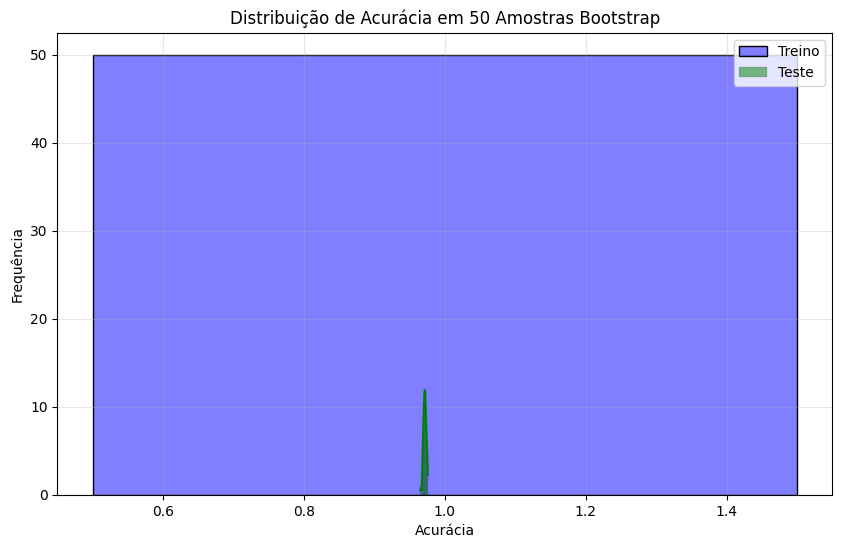

--- Resultados do Bootstrap (50 iterações) ---
Acurácia Média no TREINO: 1.0000 (Desvio Padrão: 0.0000)
Acurácia Média no TESTE:  0.9715  (Desvio Padrão: 0.0021)

Interpretação:
-> O modelo memoriza consistentemente os dados de treino (Overfitting confirmado).
-> O modelo é muito ESTÁVEL no teste, apesar do overfitting (o que é ótimo).


In [ ]:
from sklearn.utils import resample
import numpy as np

print("Iniciando análise de estabilidade via Bootstrap (50 iterações)...")

# Configurações
n_iterations = 50
bootstrap_train_scores = []
bootstrap_test_scores = []

# Loop de Bootstrap
for i in range(n_iterations):
    # 1. Criar uma amostra com reposição (bootstrap sample) dos dados de treino
    # Isso simula variações nos dados de entrada
    X_boot, y_boot = resample(X_train_rf, y_train_rf, replace=True, random_state=i)

    # 2. Treinar o modelo padrão com essa amostra
    model_boot = RandomForestClassifier(n_estimators=100, n_jobs=-1) # Sem random_state fixo para variar
    model_boot.fit(X_boot, y_boot)

    # 3. Avaliar
    # Acurácia na amostra de treino (Bootstrap)
    acc_train = accuracy_score(y_boot, model_boot.predict(X_boot))
    # Acurácia no conjunto de teste original (para ver a generalização)
    acc_test = accuracy_score(y_test_rf, model_boot.predict(X_test_rf))

    bootstrap_train_scores.append(acc_train)
    bootstrap_test_scores.append(acc_test)

# --- Visualização dos Resultados ---
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_train_scores, color='blue', label='Treino', alpha=0.5, kde=True)
sns.histplot(bootstrap_test_scores, color='green', label='Teste', alpha=0.5, kde=True)
plt.title(f'Distribuição de Acurácia em {n_iterations} Amostras Bootstrap')
plt.xlabel('Acurácia')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Estatísticas Finais ---
print(f"--- Resultados do Bootstrap ({n_iterations} iterações) ---")
print(f"Acurácia Média no TREINO: {np.mean(bootstrap_train_scores):.4f} (Desvio Padrão: {np.std(bootstrap_train_scores):.4f})")
print(f"Acurácia Média no TESTE:  {np.mean(bootstrap_test_scores):.4f}  (Desvio Padrão: {np.std(bootstrap_test_scores):.4f})")

print("\nInterpretação:")
if np.mean(bootstrap_train_scores) > 0.99:
    print("-> O modelo memoriza consistentemente os dados de treino (Overfitting confirmado).")
if np.std(bootstrap_test_scores) < 0.01:
    print("-> O modelo é muito ESTÁVEL no teste, apesar do overfitting (o que é ótimo).")
else:
    print("-> O modelo tem alta variância no teste (o desempenho varia muito dependendo dos dados).")

--- Iniciando Validação de Hipóteses (Pedido do Parceiro) ---
Testando: 1. Todas as Features...
Testando: 2. Apenas Massa e Raio (Físicos)...
Testando: 3. Apenas Órbita e Estrela (Posicionais)...

--- RESULTADOS FINAIS ---


,Cenário,RF Acc,KNN Acc
0,1. Todas as Features,0.973952,0.931385
1,2. Apenas Massa e Raio (Físicos),0.981576,0.968234
2,3. Apenas Órbita e Estrela (Posicionais),0.599746,0.499365


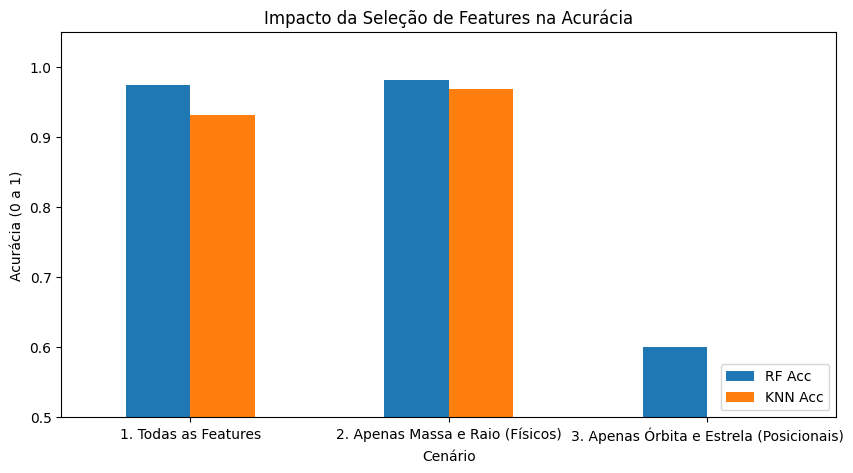

In [20]:
def treinar_avaliar_rapido(model_name, X, y, scale=False):
    # Divisão simples
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # Escalonamento (se necessário, ex: para KNN)
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    # Definição do Modelo
    if model_name == 'RF':
        model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    elif model_name == 'KNN':
        model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

    # Treino e Avaliação
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)

# --- 2. Função Principal de Validação de Hipóteses (CORRIGIDA) ---
def executar_validacao_hipoteses(df_entrada):
    print("--- Iniciando Validação de Hipóteses (Pedido do Parceiro) ---")

    target_col = 'planet_type'
    y = df_entrada[target_col]

    # Definição dos Cenários de Features
    cenarios = {
        '1. Todas as Features': [
            'mass_multiplier', 'radius_multiplier', 'orbital_radius',
            'orbital_period', 'eccentricity', 'stellar_magnitude'
        ],
        '2. Apenas Massa e Raio (Físicos)': [
            'mass_multiplier', 'radius_multiplier'
        ],
        '3. Apenas Órbita e Estrela (Posicionais)': [
            'orbital_radius', 'orbital_period', 'eccentricity', 'stellar_magnitude'
        ]
    }

    resultados_dict = {'Cenário': [], 'RF Acc': [], 'KNN Acc': []}

    for nome_cenario, cols in cenarios.items():
        print(f"Testando: {nome_cenario}...")
        try:
            X = df_entrada[cols]

            # Treina RF (sem scale) e KNN (com scale)
            acc_rf = treinar_avaliar_rapido('RF', X, y, scale=False)
            acc_knn = treinar_avaliar_rapido('KNN', X, y, scale=True)

            resultados_dict['Cenário'].append(nome_cenario)
            resultados_dict['RF Acc'].append(acc_rf)
            resultados_dict['KNN Acc'].append(acc_knn)
        except KeyError as e:
            print(f"Erro: Coluna não encontrada no DataFrame: {e}")
            return

    # Criação do DataFrame de Resultados
    df_resultados = pd.DataFrame(resultados_dict)

    print("\n--- RESULTADOS FINAIS ---")
    # CORREÇÃO AQUI: Removemos o .style para não depender do jinja2
    display(df_resultados)

    # Plotagem
    df_resultados.set_index('Cenário').plot(kind='bar', figsize=(10, 5))
    plt.title('Impacto da Seleção de Features na Acurácia')
    plt.ylabel('Acurácia (0 a 1)')
    plt.ylim(0.5, 1.05)
    plt.xticks(rotation=0)
    plt.legend(loc='lower right')
    plt.show()

# --- Execução ---
if 'df_reg' in locals():
    executar_validacao_hipoteses(df_reg)
else:
    print("❌ ERRO: df_reg não encontrado. Rode a imputação primeiro.")